In [2]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])


In [5]:
splits = ["train", "val", "test"]
datasets_dict = {split: datasets.ImageFolder(f"data_split/{split}", transform=transform) for split in splits}
loaders_dict = {split: DataLoader(datasets_dict[split], batch_size=16, shuffle=False) for split in splits}



In [6]:
model = models.mobilenet_v2(pretrained=False)
model.classifier = torch.nn.Sequential(
    torch.nn.Linear(model.last_channel, 128),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(128,1),
    torch.nn.Sigmoid()
)


d:\2025 12 20 Backup Desktop\smoke\venv\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\2025 12 20 Backup Desktop\smoke\venv\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [7]:
model.load_state_dict(torch.load("mobilenetv2_pneumonia.pth", map_location=device))
model.to(device)
model.eval()


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
def evaluate(loader):
    y_true, y_prob = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images).cpu().numpy()
            y_prob.extend(outputs)
            y_true.extend(labels.numpy())
    y_pred = [1 if p>0.5 else 0 for p in y_prob]
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    return y_true, y_pred, y_prob, acc, f1, roc


--- TRAIN ---
Accuracy: 0.9985, F1: 0.9985, ROC-AUC: 1.0000


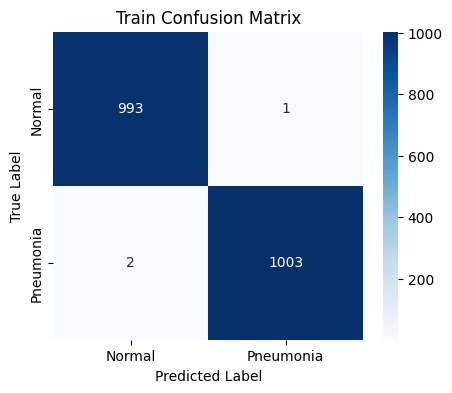

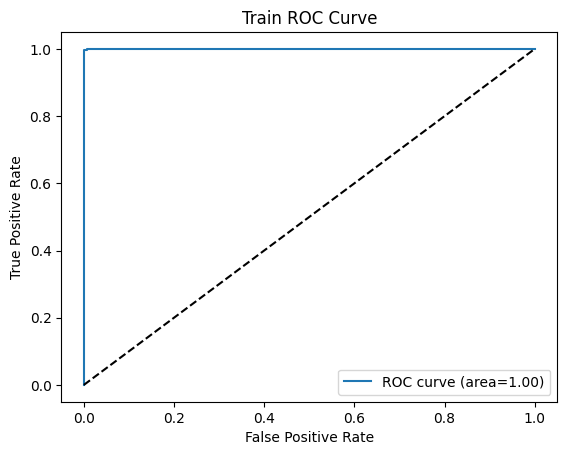

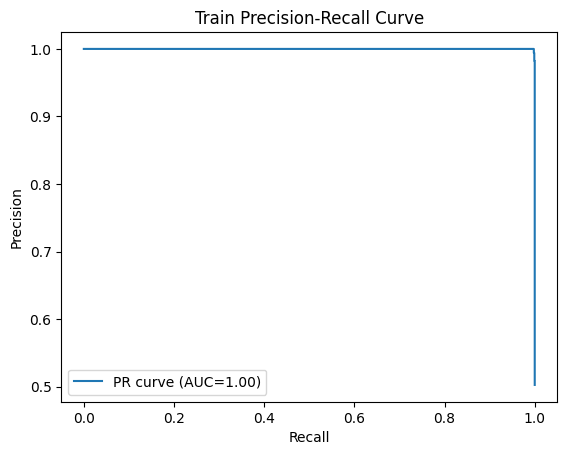

--- VAL ---
Accuracy: 0.9979, F1: 0.9980, ROC-AUC: 1.0000


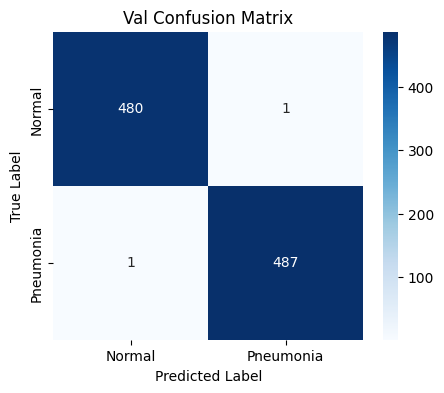

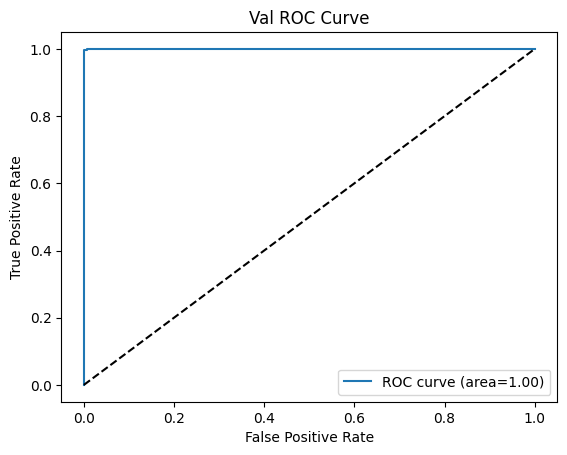

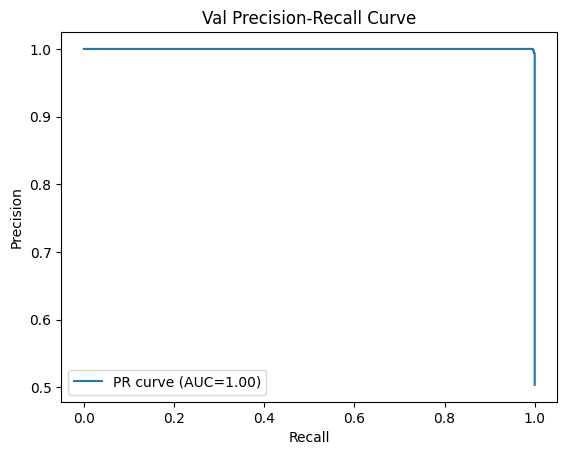

--- TEST ---
Accuracy: 0.9980, F1: 0.9980, ROC-AUC: 1.0000


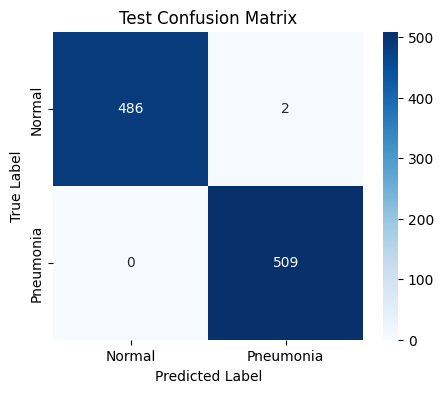

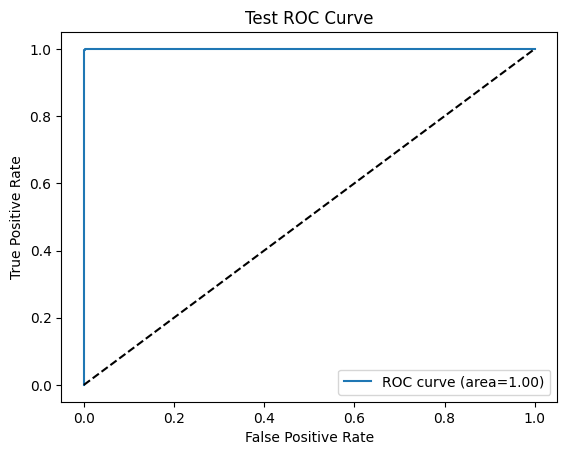

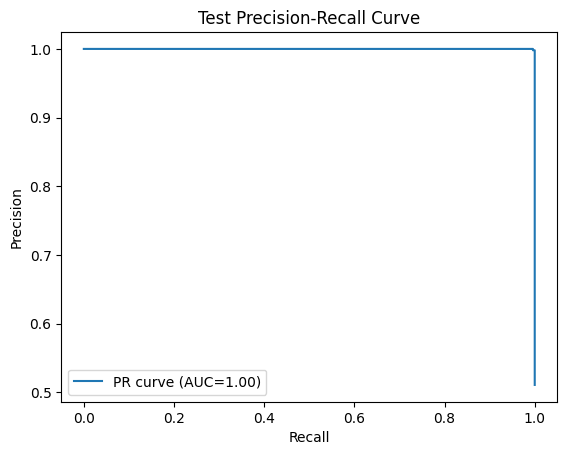

In [9]:
for split in splits:
    y_true, y_pred, y_prob, acc, f1, roc = evaluate(loaders_dict[split])
    print(f"--- {split.upper()} ---")
    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}, ROC-AUC: {roc:.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","Pneumonia"], yticklabels=["Normal","Pneumonia"])
    plt.title(f"{split.capitalize()} Confusion Matrix")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

    # ROC Curve
    from sklearn.metrics import roc_curve
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)
    plt.figure()
    plt.plot(fpr, tpr, label=f"ROC curve (area={roc:.2f})")
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{split.capitalize()} ROC Curve")
    plt.legend()
    plt.show()

    # Precision-Recall Curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall, precision)
    plt.figure()
    plt.plot(recall, precision, label=f"PR curve (AUC={pr_auc:.2f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{split.capitalize()} Precision-Recall Curve")
    plt.legend()
    plt.show()
